<a href="https://colab.research.google.com/github/ahersakshi/Major_Sakshi/blob/main/Major.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential , Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2 , VGG16
from tensorflow.keras.optimizers import Adam

import os
import random

import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
import zipfile

# Set Kaggle credentials
os.environ['KAGGLE_USERNAME'] = "sakshiravindraaher"
os.environ['KAGGLE_KEY'] = "5a19f4fdc58ebbd4d2f2083490a61a05"

# Install Kaggle API if not already installed
!pip install -q kaggle

# Download dataset using Kaggle API
!kaggle datasets download -d nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone

# Extract the dataset
with zipfile.ZipFile('ct-kidney-dataset-normal-cyst-tumor-and-stone.zip', 'r') as zip_ref:
    zip_ref.extractall('kidney_dataset')

print("Dataset downloaded and extracted successfully!")


Dataset URL: https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone
License(s): copyright-authors
Dataset downloaded and extracted successfully!


In [5]:
import tensorflow as tf
from tensorflow import keras

# Set new data path after extraction
data_path = 'kidney_dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'

# Set seed for reproducibility
seed = 123

# Create the training dataset with a validation split
train_ds = keras.utils.image_dataset_from_directory(
    data_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150),
    validation_split=0.2,
    subset='training',
    seed=seed
)

# Create the validation dataset
val_ds = keras.utils.image_dataset_from_directory(
    data_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150),
    validation_split=0.2,
    subset='validation',
    seed=seed
)

# Optional: Prefetch to improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Datasets loaded successfully!")


Found 12446 files belonging to 4 classes.
Using 9957 files for training.
Found 12446 files belonging to 4 classes.
Using 2489 files for validation.
Datasets loaded successfully!


In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [7]:
# load MobilenetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# Training MobileNetV2
history_mobilenet = model.fit(train_ds, epochs=30, validation_data=val_ds)

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 53s 128ms/step - accuracy: 0.5320 - loss: 1.2463 - val_accuracy: 0.7682 - val_loss: 0.6300
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7507 - loss: 0.6644 - val_accuracy: 0.8409 - val_loss: 0.4709
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8119 - loss: 0.5173 - val_accuracy: 0.8722 - val_loss: 0.3789
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8483 - loss: 0.4318 - val_accuracy: 0.8927 - val_loss: 0.3135
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8790 - loss: 0.3601 - val_accuracy: 0.9116 - val_loss: 0.2696
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8974 - loss: 0.3115 - val_accuracy: 0.9188 - val_loss: 0.2305
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9132 - loss: 0.2740 - val_accuracy: 0.9353 - val_loss: 0.1999
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9257 - loss: 0.2368 - val_a

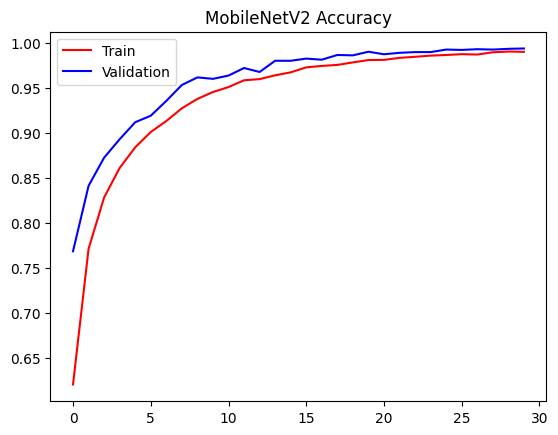

In [11]:
plt.title('MobileNetV2 Accuracy')

plt.plot(history_mobilenet.history['accuracy'], color='red',label='Train')
plt.plot(history_mobilenet.history['val_accuracy'], color='blue',label='Validation')

plt.legend()+

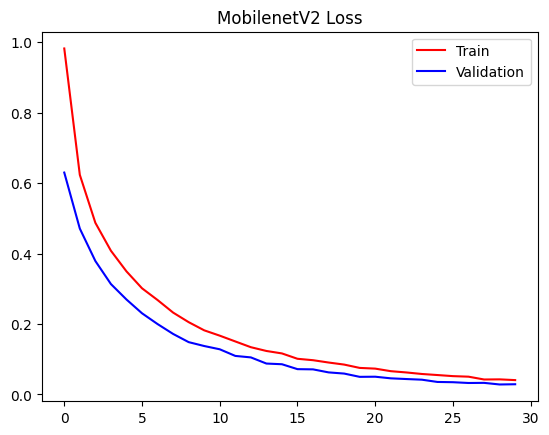

In [12]:
plt.title('MobilenetV2 Loss')

plt.plot(history_mobilenet.history['loss'], color='red',label='Train')
plt.plot(history_mobilenet.history['val_loss'], color='blue',label='Validation')

plt.legend()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(val_ds)
y_pred_classes = y_pred.argmax(axis=1)

y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)

print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       737
           1       0.99      1.00      1.00      1001
           2       1.00      0.95      0.97       280
           3       1.00      1.00      1.00       471

    accuracy                           0.99      2489
   macro avg       0.99      0.99      0.99      2489
weighted avg       0.99      0.99      0.99      2489

[[ 736    0    0    1]
 [   0 1000    1    0]
 [   5    7  267    1]
 [   0    1    0  470]]


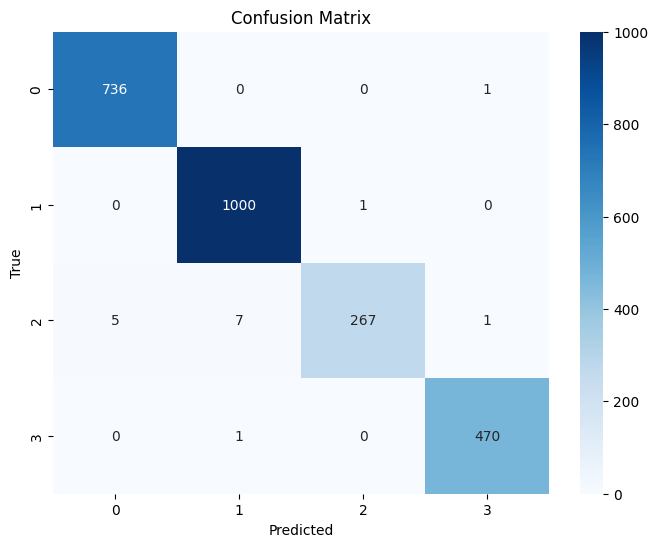

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
